# Understanding the Line Chart

A line chart connects observations in the **order they occurred** — typically time. It is the standard tool for time-series data, making trends, cycles, seasonality, and anomalies immediately visible.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

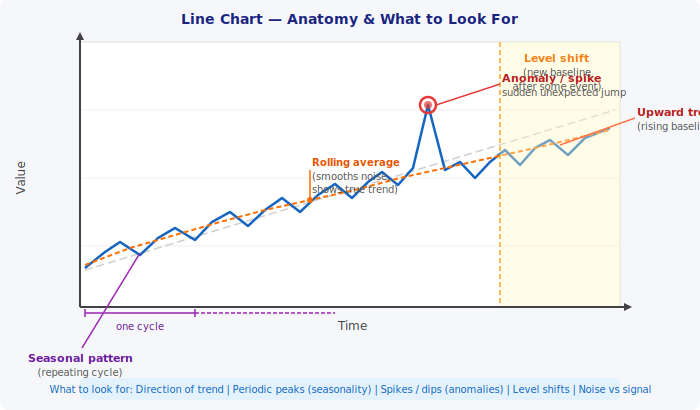

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="410"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="410" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Line Chart — Anatomy &amp; What to Look For</text>

  <!-- plot area -->
  <rect x="80" y="42" width="540" height="265" fill="white" stroke="#E0E0E0"/>

  <!-- gridlines -->
  <line x1="80" y1="110" x2="620" y2="110" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="80" y1="178" x2="620" y2="178" stroke="#F0F0F0" stroke-width="1"/>
  <line x1="80" y1="246" x2="620" y2="246" stroke="#F0F0F0" stroke-width="1"/>

  <!-- Underlying trend line (dashed) -->
  <line x1="85" y1="270" x2="615" y2="110" stroke="#9E9E9E" stroke-width="1.5"
        stroke-dasharray="8,4" opacity="0.5"/>

  <!-- Main time series: upward trend with seasonal oscillation and one spike -->
  <!-- Path points: approximate sine wave on rising baseline, spike at ~x=430 -->
  <polyline
    points="85,268  105,252  120,242  140,255  158,238  175,228  195,240  212,222
            230,212  248,226  265,210  282,198  300,212  318,195  335,184
            352,198  368,182  382,172  398,185  413,168  428,105  445,170
            460,162  475,178  490,162  505,150  520,165  535,148  550,140
            568,155  585,138  610,128"
    fill="none" stroke="#1565C0" stroke-width="2.5" stroke-linejoin="round"/>

  <!-- Rolling average (smooth orange line) -->
  <polyline
    points="85,265  130,248  175,235  220,222  265,210  310,200  355,190
            400,178  445,168  490,158  535,148  610,130"
    fill="none" stroke="#FF6F00" stroke-width="2" stroke-dasharray="5,3"
    stroke-linejoin="round"/>

  <!-- Anomaly spike highlight -->
  <circle cx="428" cy="105" r="8" fill="none" stroke="#E53935" stroke-width="2.5"/>
  <circle cx="428" cy="105" r="4" fill="#E53935" opacity="0.7"/>

  <!-- Level shift region (shaded) -->
  <rect x="500" y="42" width="120" height="265" fill="#FFF9C4" opacity="0.4"/>
  <line x1="500" y1="42" x2="500" y2="307" stroke="#F9A825" stroke-width="1.5"
        stroke-dasharray="5,3"/>

  <!-- Seasonal bracket (first two cycles visible) -->
  <line x1="85"  y1="313" x2="195" y2="313" stroke="#9C27B0" stroke-width="1.5"/>
  <line x1="195" y1="313" x2="335" y2="313" stroke="#9C27B0" stroke-width="1.5"
        stroke-dasharray="4,2"/>
  <line x1="85"  y1="309" x2="85"  y2="317" stroke="#9C27B0" stroke-width="1.5"/>
  <line x1="195" y1="309" x2="195" y2="317" stroke="#9C27B0" stroke-width="1.5"/>
  <text x="140" y="330" text-anchor="middle" font-size="10" fill="#6A1B9A">one cycle</text>

  <!-- axes -->
  <line x1="80" y1="307" x2="624" y2="307" stroke="#424242" stroke-width="2"/>
  <line x1="80" y1="307" x2="80"  y2="40"  stroke="#424242" stroke-width="2"/>
  <polygon points="624,303 632,307 624,311" fill="#424242"/>
  <polygon points="76,40 80,32 84,40" fill="#424242"/>
  <text x="352" y="330" text-anchor="middle" font-size="12" fill="#424242">Time</text>
  <text x="25" y="178" text-anchor="middle" font-size="12" fill="#424242"
        transform="rotate(-90 25 178)">Value</text>

  <!-- ── ANNOTATIONS ── -->

  <!-- Trend -->
  <line x1="560" y1="145" x2="635" y2="118" stroke="#FF7043" stroke-width="1.5"/>
  <text x="637" y="116" font-size="11" font-weight="bold" fill="#B71C1C">Upward trend</text>
  <text x="637" y="130" font-size="10" fill="#555">(rising baseline)</text>

  <!-- Rolling average label -->
  <line x1="310" y1="200" x2="310" y2="170" stroke="#FF6F00" stroke-width="1.5"/>
  <circle cx="310" cy="200" r="3" fill="#FF6F00"/>
  <text x="312" y="166" font-size="10" fill="#E65100" font-weight="bold">Rolling average</text>
  <text x="312" y="180" font-size="10" fill="#555">(smooths noise,</text>
  <text x="312" y="193" font-size="10" fill="#555">shows true trend)</text>

  <!-- Anomaly -->
  <line x1="436" y1="105" x2="500" y2="84" stroke="#E53935" stroke-width="1.5"/>
  <text x="502" y="82" font-size="11" font-weight="bold" fill="#B71C1C">Anomaly / spike</text>
  <text x="502" y="96" font-size="10" fill="#555">sudden unexpected jump</text>

  <!-- Seasonal pattern -->
  <line x1="140" y1="253" x2="82" y2="348" stroke="#9C27B0" stroke-width="1.5"/>
  <text x="80" y="362" text-anchor="middle" font-size="11" font-weight="bold" fill="#6A1B9A">Seasonal pattern</text>
  <text x="80" y="376" text-anchor="middle" font-size="10" fill="#555">(repeating cycle)</text>

  <!-- Level shift -->
  <text x="557" y="62" text-anchor="middle" font-size="11" font-weight="bold" fill="#F57F17">Level shift</text>
  <text x="557" y="76" text-anchor="middle" font-size="10" fill="#555">(new baseline</text>
  <text x="557" y="90" text-anchor="middle" font-size="10" fill="#555">after some event)</text>

  <!-- Takeaway -->
  <rect x="80" y="378" width="540" height="22" fill="#E3F2FD" rx="4"/>
  <text x="350" y="393" text-anchor="middle" font-size="10" fill="#1565C0">
    What to look for:  Direction of trend  |  Periodic peaks (seasonality)  |  Spikes / dips (anomalies)  |  Level shifts  |  Noise vs signal
  </text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Line Chart

| Feature | What it tells you |
|---|---|
| **Rising / falling line** | Upward / downward trend over time |
| **Repeating peaks and troughs** | Seasonality — periodic pattern |
| **Sudden isolated spike** | Anomaly — event, error, or sensor malfunction |
| **Abrupt jump in baseline** | Level shift — structural change in the system |
| **Irregular jaggedness** | High noise — consider smoothing (rolling average) |
| **Smooth rolling average** | Underlying signal without noise |
| **Multiple lines** | Compare trends for different groups or series |

**Order matters**: a line chart only makes sense when the x-axis has a meaningful ordering (time, run sequence). For unordered categories, use a bar chart instead.

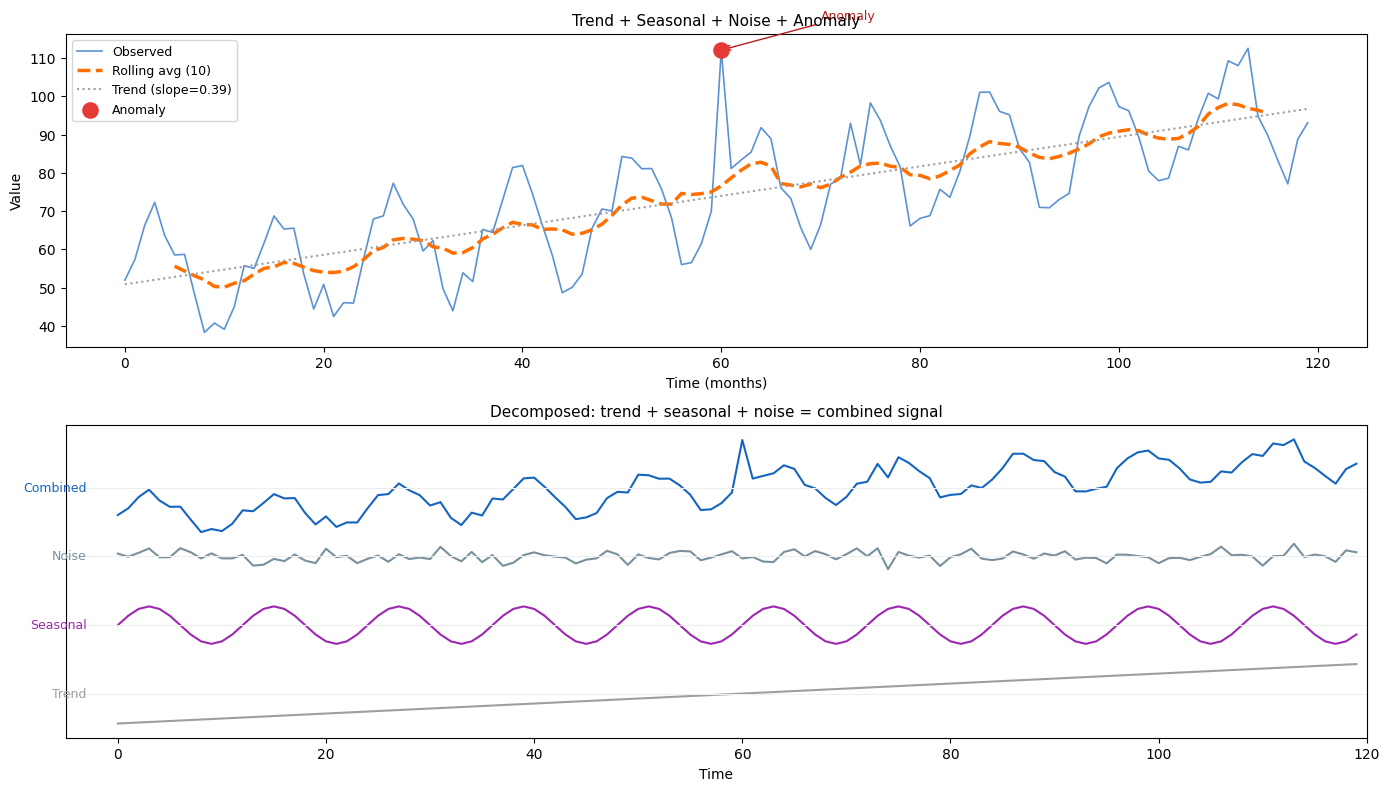

In [3]:
np.random.seed(42)
n = 120
t = np.arange(n)

# Trend + seasonal + noise + one anomaly
trend    = 0.4 * t
seasonal = 15 * np.sin(2 * np.pi * t / 12)
noise    = np.random.randn(n) * 4
signal   = trend + seasonal + noise + 50
# inject anomaly
signal[60] += 40

rolling = pd.Series(signal).rolling(window=10, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full annotated chart
axes[0].plot(signal, color='#1565C0', linewidth=1.2, alpha=0.7, label='Observed')
axes[0].plot(rolling, color='#FF6F00', linewidth=2.5, linestyle='--', label='Rolling avg (10)')
# Trend line
m, b = np.polyfit(t, signal, 1)
axes[0].plot(t, m*t + b, color='#9E9E9E', linewidth=1.5, linestyle=':', label=f'Trend (slope={m:.2f})')
# Anomaly marker
axes[0].scatter([60], [signal[60]], color='#E53935', s=120, zorder=5, label='Anomaly')
axes[0].annotate('Anomaly', xy=(60, signal[60]), xytext=(70, signal[60]+8),
                 fontsize=9, color='#B71C1C',
                 arrowprops=dict(arrowstyle='->', color='#B71C1C'))
axes[0].set_title('Trend + Seasonal + Noise + Anomaly', fontsize=11)
axes[0].set_xlabel('Time (months)')
axes[0].set_ylabel('Value')
axes[0].legend(fontsize=9)

# Decomposed view
components = [trend + 50, seasonal, noise, signal]
labels = ['Trend', 'Seasonal', 'Noise', 'Combined']
colors = ['#9E9E9E', '#9C27B0', '#78909C', '#1565C0']
for i, (comp, label, color) in enumerate(zip(components, labels, colors)):
    offset = i * 55
    axes[1].plot(comp - comp.mean() + offset, color=color, linewidth=1.5, label=label)
    axes[1].axhline(offset, color='#EEE', linewidth=0.8)
    axes[1].text(-3, offset, label, ha='right', va='center', fontsize=9, color=color)

axes[1].set_title('Decomposed: trend + seasonal + noise = combined signal', fontsize=11)
axes[1].set_xlabel('Time')
axes[1].set_yticks([])
axes[1].set_xlim(-5, n)

plt.tight_layout()
plt.show()

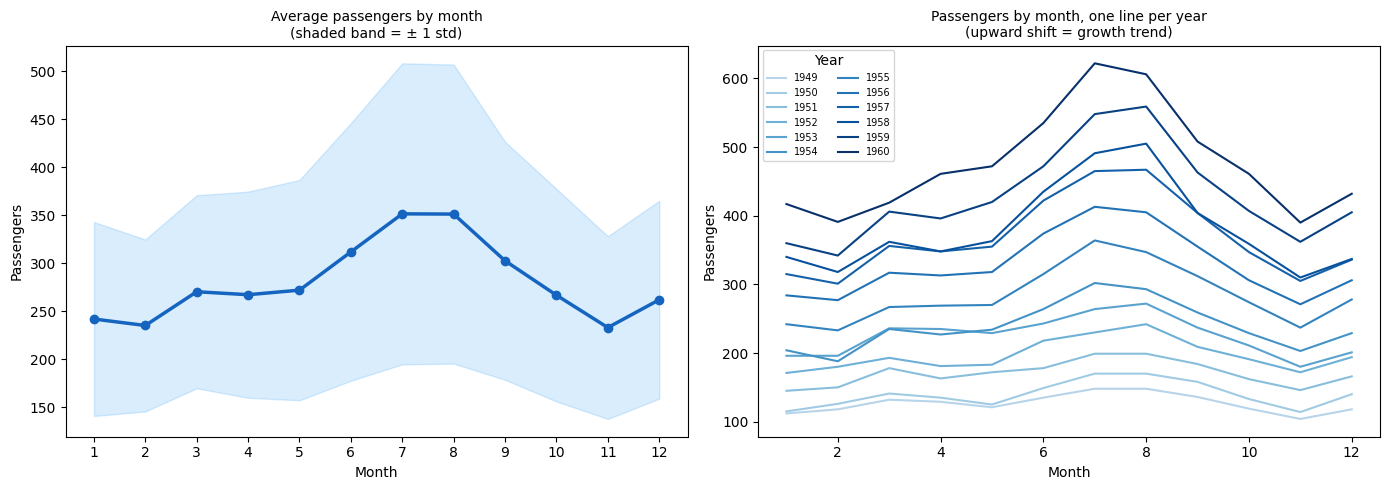

In [4]:
# Multiple lines: compare groups over time
flights = sns.load_dataset('flights')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single line with shaded band
monthly_avg = flights.groupby('month')['passengers'].mean()
monthly_std = flights.groupby('month')['passengers'].std()
x = np.arange(1, 13)
axes[0].plot(x, monthly_avg, color='#1565C0', linewidth=2.5, marker='o', markersize=6)
axes[0].fill_between(x, monthly_avg - monthly_std, monthly_avg + monthly_std,
                     alpha=0.2, color='#42A5F5')
axes[0].set_title('Average passengers by month\n(shaded band = ± 1 std)', fontsize=10)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Passengers')
axes[0].set_xticks(x)

# Multiple lines: one per year
palette = plt.cm.Blues(np.linspace(0.3, 1.0, flights['year'].nunique()))
for (year, group), color in zip(flights.groupby('year'), palette):
    axes[1].plot(group['month'].cat.codes + 1, group['passengers'],
                 color=color, linewidth=1.5, label=str(year))
axes[1].set_title('Passengers by month, one line per year\n(upward shift = growth trend)', fontsize=10)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Passengers')
axes[1].legend(title='Year', fontsize=7, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Time-ordered data — trends, cycles, anomalies |
| **Trend** | Overall direction (up/down/flat) |
| **Seasonality** | Regular repeating pattern |
| **Anomaly** | Isolated spike / dip — investigate cause |
| **Rolling average** | Removes noise, reveals underlying signal |
| **Multiple lines** | Compare trends across groups |
| **Not for** | Unordered categories — use bar chart instead |